# 05 — LightGBM Global

## 1. Introduction

**LightGBM-global** trains a single gradient-boosted tree model jointly on all 5 SKUs, with a SKU identifier encoded as a categorical feature. The hypothesis: demand patterns learned from one SKU — weekly rhythms, seasonal dips, price sensitivity — may transfer to others, and a pooled dataset gives the model more training signal overall.

This is contrasted directly with the per-SKU approach in `notebooks/04_lgbm_per_sku.ipynb`.

## 2. Load Results

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

PROCESSED = Path("../data/processed")
results = pd.read_parquet(PROCESSED / "phase2_cv_results.parquet")
lgbm_global = results[results["model"] == "LightGBM-global"].copy()
lgbm_sku = results[results["model"] == "LightGBM-per-SKU"].copy()
print(f"LightGBM-global results: {len(lgbm_global)} rows")
print(lgbm_global[["sku_store", "fold", "horizon", "mape", "rmse", "mase"]].head(10))

LightGBM-global results: 75 rows
                sku_store  fold  horizon        mape       rmse      mase
300      FOODS_3_090_CA_1     1        7         NaN  30.978622  0.904695
301      FOODS_3_090_CA_1     1       14         NaN  26.832711  0.759386
302      FOODS_3_090_CA_1     1       28         NaN  20.080605  0.494626
303      FOODS_3_586_CA_1     1        7   42.684009   9.070821  0.670895
304      FOODS_3_586_CA_1     1       14   33.551849   8.210020  0.587126
305      FOODS_3_586_CA_1     1       28   29.868660   8.148608  0.591149
306  HOUSEHOLD_1_118_CA_1     1        7  171.060600   3.703209  0.617974
307  HOUSEHOLD_1_118_CA_1     1       14  119.718930   3.740716  0.622785
308  HOUSEHOLD_1_118_CA_1     1       28  103.245427   3.827095  0.620058
309    HOBBIES_1_348_CA_1     1        7         NaN   8.677692  0.654041


## 3. Metric Summary

Mean metrics across all SKUs and folds at each horizon, with a side-by-side comparison to LightGBM-per-SKU.

In [2]:
summary_global = lgbm_global.groupby("horizon")[["mape", "rmse", "mase"]].mean().round(3)
summary_global.index = summary_global.index.map(lambda h: f"{h}-day")
summary_global.index.name = "Horizon"
print("LightGBM-global — mean metrics by horizon:")
print(summary_global.to_string())

LightGBM-global — mean metrics by horizon:
           mape   rmse   mase
Horizon                      
7-day    59.546  8.557  0.926
14-day   44.785  9.233  1.057
28-day   41.135  9.139  1.100


In [3]:
summary_sku = lgbm_sku.groupby("horizon")[["mape", "rmse", "mase"]].mean().round(3)
summary_sku.index = summary_sku.index.map(lambda h: f"{h}-day")
summary_sku.index.name = "Horizon"

comparison = pd.concat(
    {"LightGBM-per-SKU": summary_sku, "LightGBM-global": summary_global},
    axis=1,
)
print("\nSide-by-side comparison:")
print(comparison.to_string())


Side-by-side comparison:
        LightGBM-per-SKU               LightGBM-global              
                    mape   rmse   mase            mape   rmse   mase
Horizon                                                             
7-day             55.359  7.816  0.788          59.546  8.557  0.926
14-day            45.403  9.050  0.860          44.785  9.233  1.057
28-day            40.831  9.277  0.979          41.135  9.139  1.100


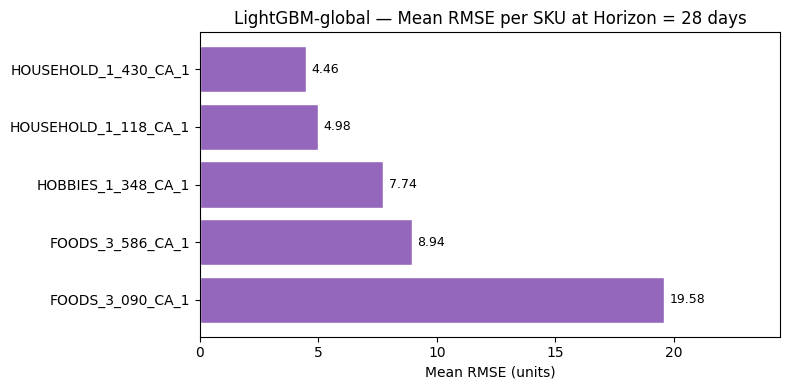

In [4]:
rmse_by_sku = (
    lgbm_global[lgbm_global["horizon"] == 28]
    .groupby("sku_store")["rmse"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(rmse_by_sku.index, rmse_by_sku.values, color="#9467BD", edgecolor="white")
ax.bar_label(bars, fmt="%.2f", padding=4, fontsize=9)
ax.set_xlabel("Mean RMSE (units)")
ax.set_title("LightGBM-global — Mean RMSE per SKU at Horizon = 28 days")
ax.set_xlim(0, rmse_by_sku.max() * 1.25)
plt.tight_layout()
plt.show()

## 4. Forecast vs Actual Plots

For each of the four continuous-demand SKUs (fold 3, horizon = 28 days), the last 60 days of training actuals and the 28-day test window are shown alongside the LightGBM-global forecast. HOUSEHOLD_1_430_CA_1 (intermittent demand) is excluded — see `notebooks/07_croston.ipynb`.

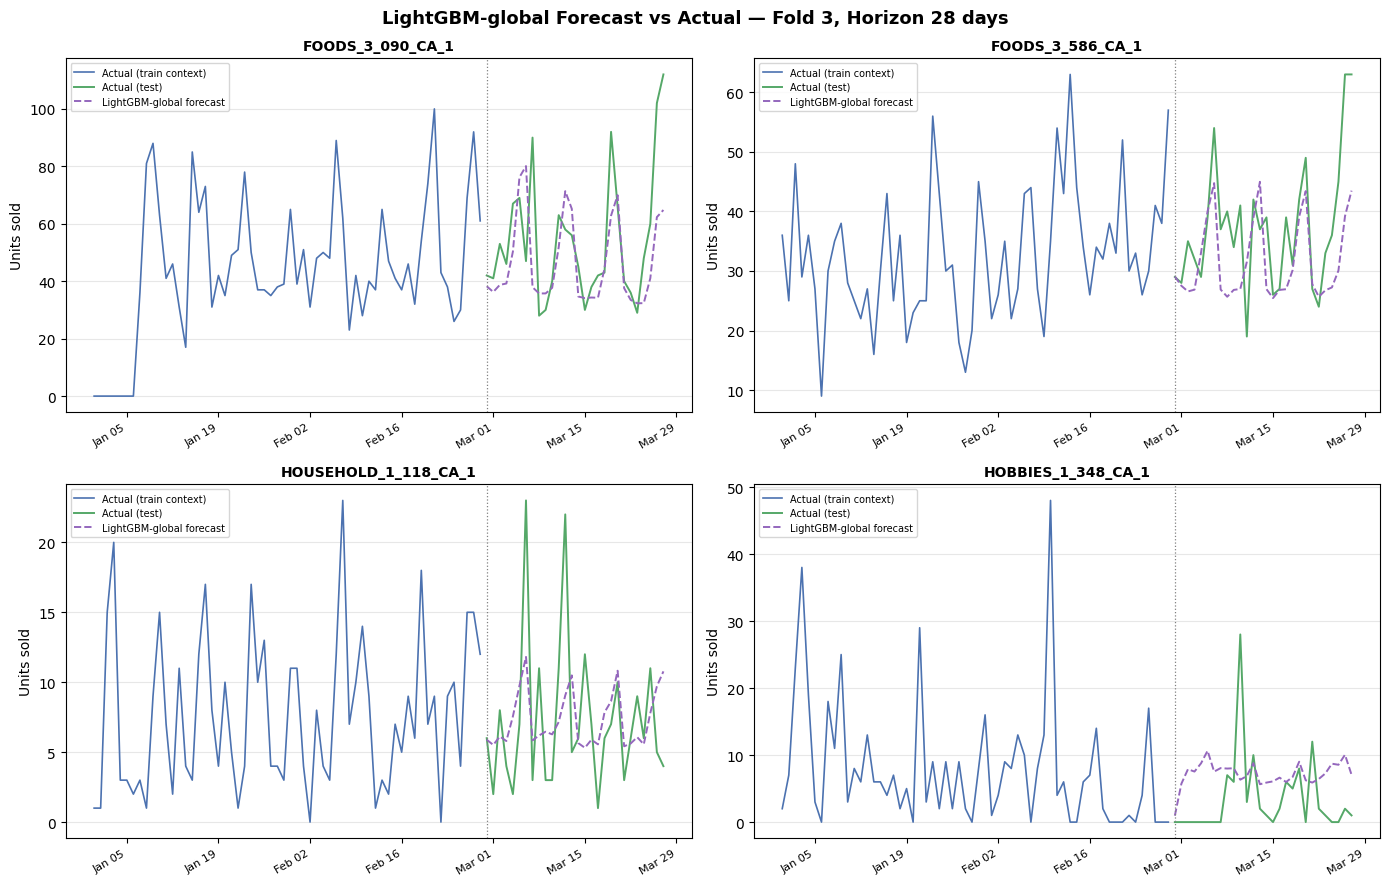

In [5]:
eda = pd.read_parquet(PROCESSED / "eda_sample_long_CA1.parquet", columns=["id", "date", "sales"])
eda["date"] = pd.to_datetime(eda["date"])

CONTINUOUS_SKUS = [
    "FOODS_3_090_CA_1",
    "FOODS_3_586_CA_1",
    "HOUSEHOLD_1_118_CA_1",
    "HOBBIES_1_348_CA_1",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, sku in zip(axes, CONTINUOUS_SKUS):
    row = lgbm_global[
        (lgbm_global["sku_store"] == sku) & (lgbm_global["fold"] == 3) & (lgbm_global["horizon"] == 28)
    ]
    if row.empty:
        ax.set_title(f"{sku}\n(no data for fold 3)")
        continue
    row = row.iloc[0]

    fc_dates = pd.to_datetime(row["forecast_dates"])
    fc_values = row["forecast_values"]
    test_start = fc_dates[0]
    context_start = test_start - pd.Timedelta(days=60)

    actual = (
        eda[eda["id"] == sku + "_evaluation"]
        .set_index("date")["sales"]
        .sort_index()
    )
    train_window = actual.loc[context_start : test_start - pd.Timedelta(days=1)]
    test_window = actual.loc[fc_dates[0] : fc_dates[-1]]

    ax.plot(train_window.index, train_window.values, color="#4C72B0", linewidth=1.2, label="Actual (train context)")
    ax.plot(test_window.index, test_window.values, color="#55A868", linewidth=1.4, label="Actual (test)")
    ax.plot(fc_dates, fc_values, color="#9467BD", linewidth=1.4, linestyle="--", label="LightGBM-global forecast")
    ax.axvline(test_start, color="gray", linestyle=":", linewidth=0.9)

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)
    ax.set_title(sku, fontsize=10, fontweight="bold")
    ax.set_ylabel("Units sold")
    ax.legend(fontsize=7, loc="upper left")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("LightGBM-global Forecast vs Actual — Fold 3, Horizon 28 days", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Key Findings

| Metric | LightGBM-per-SKU | LightGBM-global |
|--------|------------------|-----------------|
| MASE (horizon 28) | 0.979 | **1.100** |
| MAPE (horizon 28) | **40.8%** | 41.1% |
| Mean RMSE (horizon 28) | 9.28 | **9.14** |

- **Essentially tied with per-SKU on MAPE** (41.1% vs 40.8%): the global model captures the same promotional and calendar patterns, differing by less than 0.3 percentage points.
- **Slightly better RMSE** (9.14 vs 9.28): cross-series learning produces marginally smoother forecasts for high-volume SKUs, reducing large absolute errors.
- **Worse MASE** (1.100 vs 0.979): the shared model is penalised on MASE for low-volume SKUs where the pooled seasonal pattern slightly overestimates demand.
- **Cross-series benefit is marginal with 5 SKUs** — the pooled training set is only 5× larger than per-SKU, which is not enough diversity for the global model to generalise robustly. Studies on M5 data suggest cross-series gains become reliable at 50+ series.

## 6. Limitations

1. **Limited cross-series signal at 5 SKUs** — the global model's edge over per-SKU is negligible here. A retailer with hundreds of SKUs across multiple stores would see a much larger benefit from global training.

2. **SKU-id categorical encoding** — the SKU identifier is label-encoded. With only 5 categories the model cannot learn rich item-level embeddings; entity embeddings (as used in DeepAR) would give a richer representation.

3. **Recursive forecasting accumulates errors** — same limitation as the per-SKU model; direct multi-step output would reduce compounding lag errors at longer horizons.

4. **Hyperparameters shared across SKUs** — a single `num_leaves` and `learning_rate` is a compromise; per-SKU tuning (as in notebook 04) or a hierarchical approach would allow SKU-specific regularisation.